# 03 - Analyse Apriori des Combinaisons de Competences

Ce notebook utilise l'algorithme Apriori pour identifier les associations frequentes entre competences.

Objectifs:
- extraire les itemsets frequents
- generer des regles d'association
- interpreter les regles les plus utiles pour les recommandations skills

In [54]:
import pandas as pd  
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import joblib

## Etape 1 - Chargement du dataset encode

On charge le dataset issu du notebook Random Forest et on verifie sa structure.

In [55]:
df = pd.read_csv('dataset_encode.csv')
print(df.shape)

(10197, 63)


## Etape 2 - Selection des colonnes skills

On retire les colonnes de contexte (poste, entreprise, salaire, etc.) pour garder uniquement les variables de competences.

In [56]:
print(df.columns.tolist())

['job_title', 'company', 'location', 'post_date', 'seniority_level', 'skills', 'salary', 'skills_clean', 'python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer', 'job_category_software engineer']


In [57]:
# Colonnes a exclure
non_skills = ['job_title', 'company', 'location', 'post_date', 
              'seniority_level', 'skills', 'salary', 'seniority_encoded',
              'job_category_data engineer', 'job_category_data scientist', 
              'job_category_ml engineer', 'job_category_software engineer','skills_clean']

# Garder seulement les skills
df_skills = df.drop(columns=non_skills)
print(df_skills.shape)
print(df_skills.head())

(10197, 50)
   python  java  javascript  aws  sql  agile  git  c#  software engineering  \
0       0     0           0    0    0      0    0   0                     0   
1       0     0           0    0    0      0    0   0                     0   
2       0     0           0    0    0      0    0   0                     0   
3       0     0           0    0    0      0    0   0                     0   
4       0     0           0    0    0      0    0   0                     0   

   c++  ...  confluence  distributed systems  sql server  \
0    0  ...           0                    0           0   
1    0  ...           0                    0           0   
2    0  ...           0                    0           0   
3    0  ...           0                    0           0   
4    0  ...           0                    0           0   

   continuous integration  software design  rest  'machine learning'  \
0                       0                0     0                   1   
1       

In [58]:
df_skills = df_skills.astype(bool)
print(df_skills.dtypes.value_counts())

bool    50
Name: count, dtype: int64


## Etape 3 - Extraction des itemsets frequents (Apriori)

On transforme les colonnes skills en booleen puis on applique Apriori avec un support minimum de 5%.

In [59]:
frequent_items = apriori(df_skills, min_support=0.05, use_colnames=True)
print(frequent_items.shape)
print(frequent_items.head(10))

(135, 2)
    support                           itemsets
0  0.343434                frozenset({python})
1  0.308718                  frozenset({java})
2  0.261548            frozenset({javascript})
3  0.248701                   frozenset({aws})
4  0.218398                   frozenset({sql})
5  0.199863                 frozenset({agile})
6  0.174169                   frozenset({git})
7  0.174561                    frozenset({c#})
8  0.171717  frozenset({software engineering})
9  0.162695                   frozenset({c++})


## Etape 4 - Generation des regles d'association

A partir des itemsets frequents, on genere des regles avec une confiance minimale de 50%.

In [60]:
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)
print(rules.shape)
print(rules[['antecedents', 'consequents', 'confidence']].head(10))

(122, 14)
               antecedents          consequents  confidence
0      frozenset({python})    frozenset({java})    0.502570
1        frozenset({java})  frozenset({python})    0.559085
2         frozenset({aws})  frozenset({python})    0.569401
3         frozenset({sql})  frozenset({python})    0.529861
4         frozenset({c++})  frozenset({python})    0.542495
5  frozenset({kubernetes})  frozenset({python})    0.547276
6      frozenset({docker})  frozenset({python})    0.530343
7       frozenset({linux})  frozenset({python})    0.538572
8          frozenset({go})  frozenset({python})    0.844779
9         frozenset({aws})    frozenset({java})    0.558754


## Etape 5 - Visualisation des meilleures combinaisons

Le graphique suivant affiche les 10 regles ayant le plus fort lift (association la plus forte).

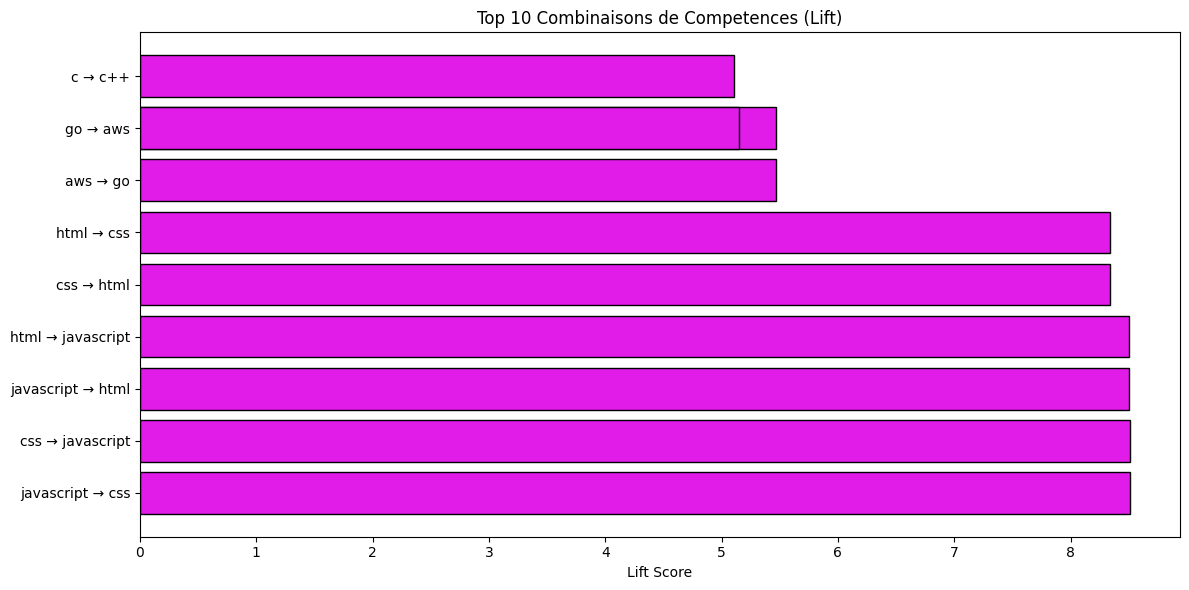

In [61]:
top_rules = rules.nlargest(10, 'lift')

plt.figure(figsize=(12, 6))
labels = [f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}" 
          for _, r in top_rules.iterrows()]
plt.barh(labels, top_rules['lift'], color="#e11be8", edgecolor='black')
plt.title('Top 10 Combinaisons de Competences (Lift)')
plt.xlabel('Lift Score')
plt.tight_layout()
plt.show()

## Interpretation et conclusion

Ce notebook met en evidence des combinaisons de competences qui apparaissent souvent ensemble.

Points cles:
- un support eleve indique une combinaison frequente dans le marche
- une confiance elevee suggere une bonne capacite de recommandation
- un lift > 1 signale une association utile (non due au hasard)

Utilisation pratique:
- enrichir le systeme de recommandation avec des skills complementaires
- proposer des parcours d'apprentissage par blocs de competences
- prioriser les combinaisons les plus demandees pour augmenter l'employabilite

In [62]:
# Supprimer skills_clean des colonnes
joblib.dump(rules, 'apriori_rules.pkl')

['apriori_rules.pkl']

In [63]:
X = df.drop(columns=['skills', 'job_title', 'seniority_level', 
                      'company', 'location', 'post_date', 'salary','skills_clean'])
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print('✅ Colonnes sauvegardées !')

✅ Colonnes sauvegardées !


In [64]:
print(rules['consequents'].head(10))
print(df.columns.tolist())

0      frozenset({java})
1    frozenset({python})
2    frozenset({python})
3    frozenset({python})
4    frozenset({python})
5    frozenset({python})
6    frozenset({python})
7    frozenset({python})
8    frozenset({python})
9      frozenset({java})
Name: consequents, dtype: object
['job_title', 'company', 'location', 'post_date', 'seniority_level', 'skills', 'salary', 'skills_clean', 'python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'dat